# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhammad Nazwar Fakhrurrozy| 5054251040|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')
print(f'Bentuk Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n')

print('Tipe Data dan Missing Values')
df.info()

print('\nstatistik deskriptif')
display(df.describe())

Bentuk Dataset: 768 baris, 9 kolom

Tipe Data dan Missing Values
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

statistik deskriptif


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Non-Diabetes (0): 500 sampel (65.10%)
Diabetes (1)    : 268 sampel (34.90%)


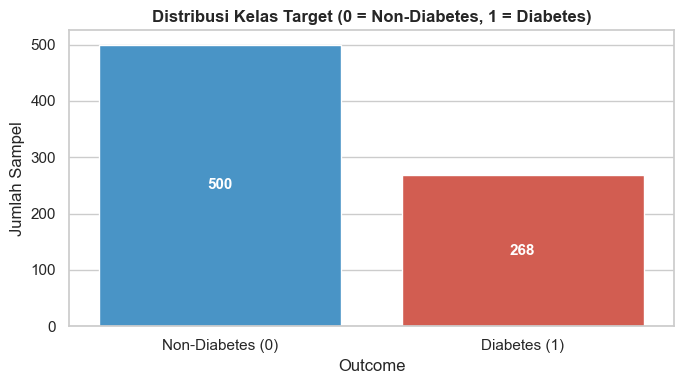

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
counts = df['Outcome'].value_counts()
pcts = df['Outcome'].value_counts(normalize=True) * 100

print(f'Non-Diabetes (0): {counts[0]} sampel ({pcts[0]:.2f}%)')
print(f'Diabetes (1)    : {counts[1]} sampel ({pcts[1]:.2f}%)')

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    x=counts.index, 
    y=counts.values, 
    hue=counts.index, 
    palette=['#3498db', '#e74c3c'], 
    legend=False
)
plt.title('Distribusi Kelas Target (0 = Non-Diabetes, 1 = Diabetes)', fontsize=12, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Sampel')
plt.xticks([0, 1], ['Non-Diabetes (0)', 'Diabetes (1)'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

data udh jelas terlihat imbalanced, harusnya resampling

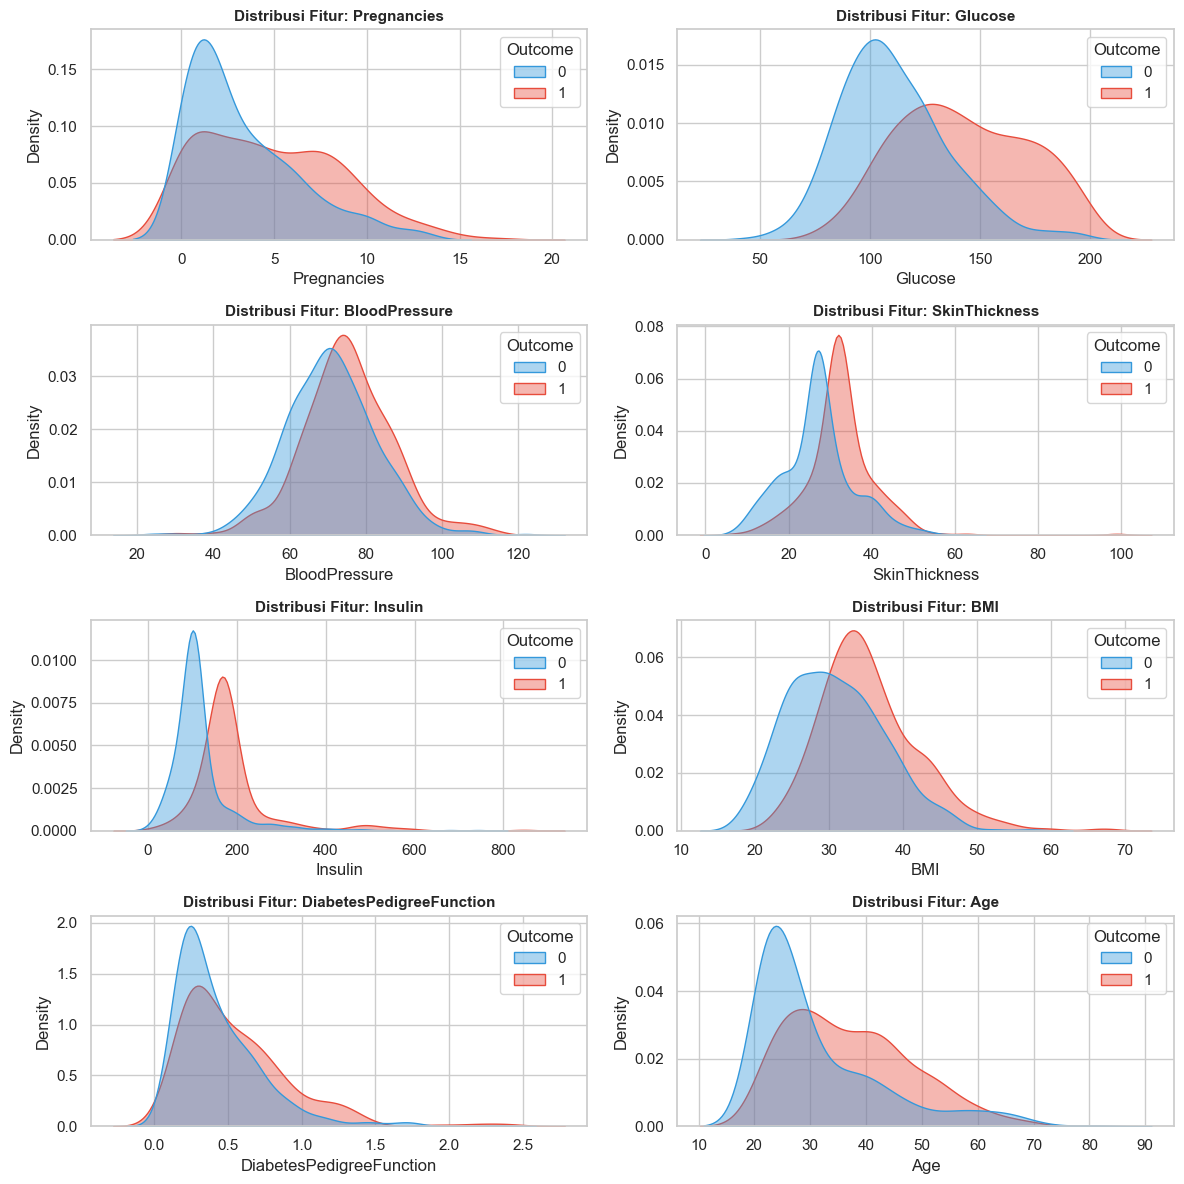

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [col for col in df.columns if col != 'Outcome']
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()
for idx, col in enumerate(features):
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='Outcome', 
        palette=['#3498db', '#e74c3c'], 
        common_norm=False, 
        fill=True, 
        alpha=0.4, 
        ax=axes[idx]
    )
    axes[idx].set_title(f'Distribusi Fitur: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.show()

Glucose menunjukkan pemisahan distribusi yang paling ngaruh, nilai Glucose tinggi mengelompok kuat pada kelas Diabetes.
BMI, Age, Insulin, dan Pregnancies mengalami pergeseran ke kanan pada kelas Diabetes, artinya nilai yang lebih tinggi berkaitan dengan risiko diabetes.
BloodPressure, SkinThickness, dan DiabetesPedigreeFunction memiliki area overlap yang gede antara kedua kelas, berarti pemisahan individual yang lebih lemah.

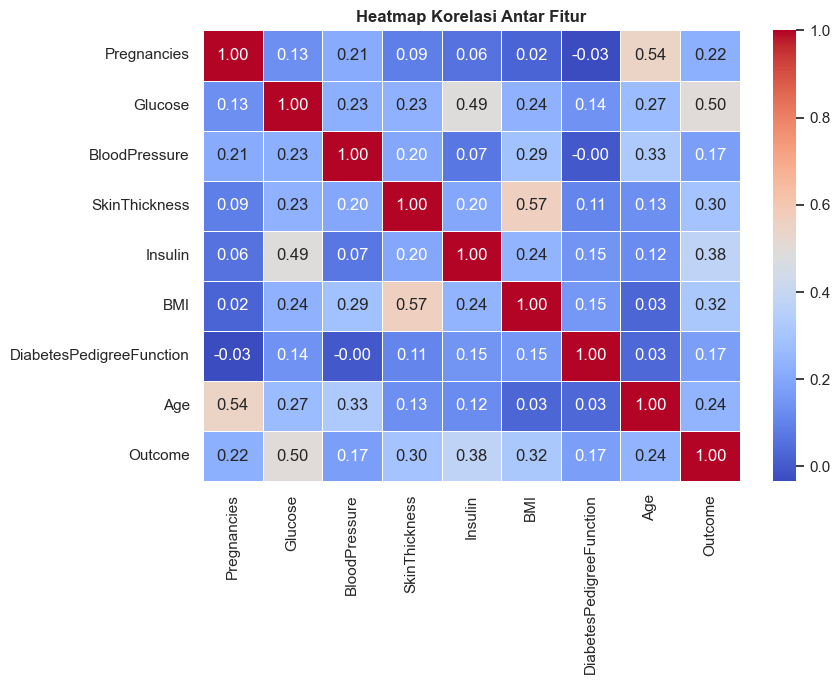

In [5]:
# Tampilkan heatmap korelasi antar fitur.
corr_matrix = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Glucose punya pengaruh paling dominan terhadap risiko diabetes, disusul oleh Insulin dan BMI.
korelasi antarsemua fitur yang tergolong cukup tinggi, yaitu BMI dengan SkinThickness Age dengan Pregnancies, serta Glucose dengan Insulin.
BloodPressure dan DiabetesPedigreeFunction memiliki korelasi paling rendah terhadap target outcome.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[zero_cols] == 0).sum()
zero_pct = (df[zero_cols] == 0).mean() * 100

zero_df = pd.DataFrame({
    'Jumlah Nilai 0': zero_counts,
    'Persentase (%)': zero_pct
})
display(zero_df)

,Jumlah Nilai 0,Persentase (%)
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


In [7]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
df_prep = df.copy()
df_prep[zero_cols] = df_prep[zero_cols].replace(0, np.nan)

print('Jumlah nilai NaN pada tiap kolom fisiologis setelah nandain:')
print(df_prep[zero_cols].isnull().sum())

Jumlah nilai NaN pada tiap kolom fisiologis setelah nandain:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [8]:
# Pisahkan fitur (X) dan target (y).
X = df_prep.drop(columns=['Outcome'])
y = df_prep['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
for col in zero_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

print(f'Ukuran X_train: {X_train.shape[0]} baris, X_test: {X_test.shape[0]} baris')
print(f'Sisa NaN di X_train:\n{X_train.isnull().sum().sum()}')

Ukuran X_train: 614 baris, X_test: 154 baris
Sisa NaN di X_train:
0


In [9]:
# Lakukan feature scaling menggunakan StandardScaler.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Bentuk data ter-skala (Train): {X_train_scaled.shape}')
print(f'Bentuk data ter-skala (Test) : {X_test_scaled.shape}')

Bentuk data ter-skala (Train): (614, 8)
Bentuk data ter-skala (Test) : (154, 8)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [10]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [11]:
# Lakukan prediksi pada test set.
y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

print(f'prediksi selesai pada {len(y_pred_gnb)} sampel data uji.')

prediksi selesai pada 154 sampel data uji.


## 3.2 Logistic Regression

In [12]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [13]:
# Lakukan prediksi pada test set.
y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print(f'prediksi selesai pada {len(y_pred_logreg)} sampel data uji.')

prediksi selesai pada 154 sampel data uji.


# 4. Evaluasi Model

In [14]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
models = [
    ('Gaussian NB', y_pred_gnb),
    ('Logistic Regression', y_pred_logreg)
]
metrics = []
for name, y_pred in models:
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


Gaussian NB unggul tipis dibanding logistic regression

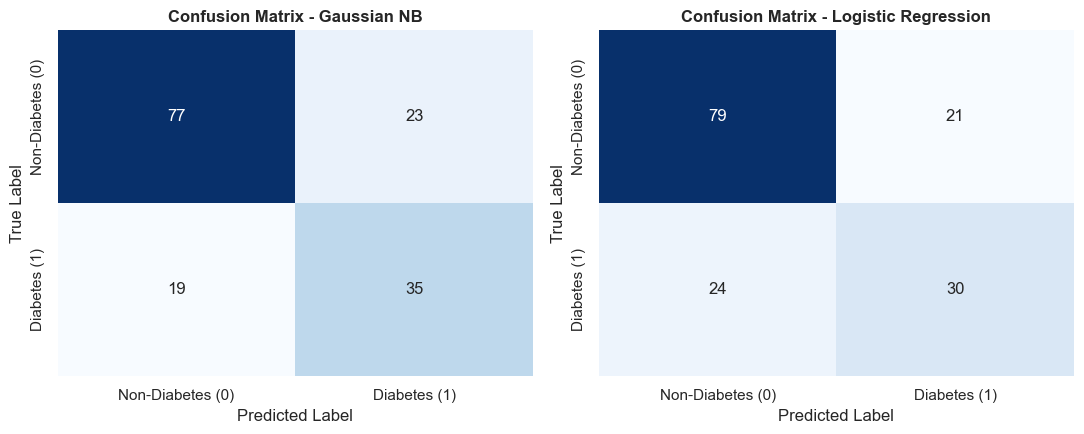

In [15]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_data = [
    ('Gaussian NB', confusion_matrix(y_test, y_pred_gnb)),
    ('Logistic Regression', confusion_matrix(y_test, y_pred_logreg))
]
for ax, (title, cm) in zip(axes, cm_data):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Non-Diabetes (0)', 'Diabetes (1)'],
                yticklabels=['Non-Diabetes (0)', 'Diabetes (1)'])
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

Kedua model masih cukup banyak meloloskan False Negative

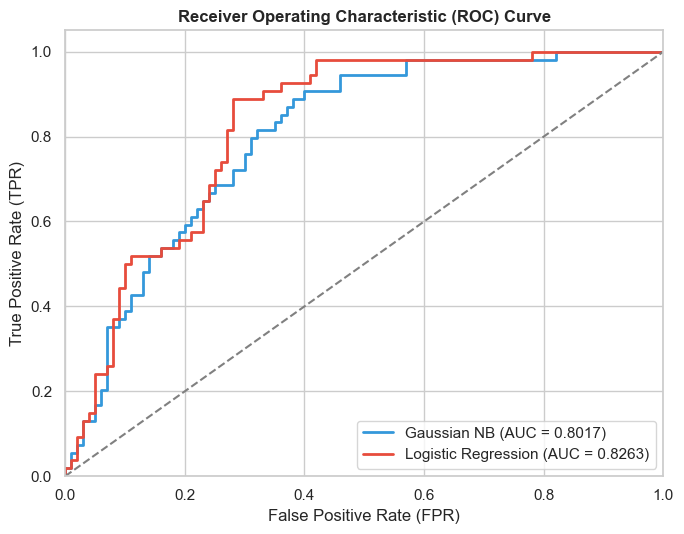

In [16]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(7, 5.5))
roc_data = [
    ('Gaussian NB', y_prob_gnb, '#3498db'),
    ('Logistic Regression', y_prob_logreg, '#e74c3c')
]
for name, y_prob, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Logistic Regression sedikit lebih baik dalam memisahkan probabilitas antar kelas

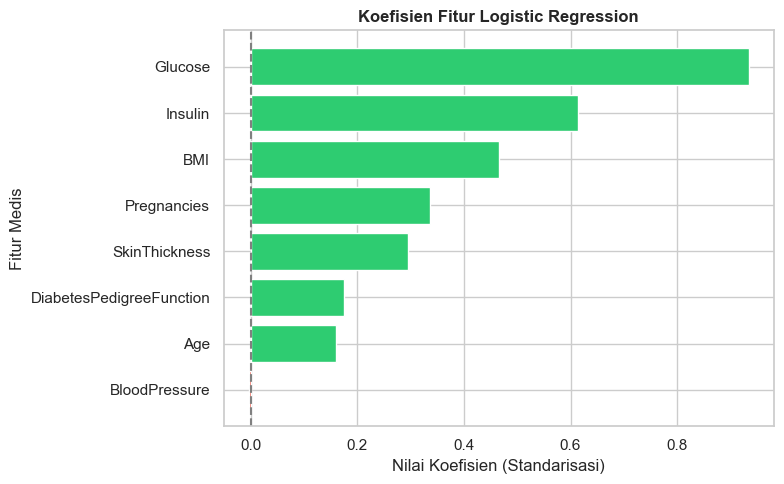

In [17]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='gray', linestyle='--')
plt.title('Koefisien Fitur Logistic Regression', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Koefisien (Standarisasi)')
plt.ylabel('Fitur Medis')
plt.tight_layout()
plt.show()

Glucose, Insulin, dan BMI menjadi 3 faktor paling dominan yang meningkatkan risiko diabetes pasien.

# 5. Analisis

Berdasarkan hasil eksperimen klasifikasi diabetes pada 154 sampel data uji, model Gaussian Naive Bayes (Gaussian NB) mencatatkan performa keseluruhan yang sedikit lebih tinggi dibanding Logistic Regression. Gaussian NB memperoleh Accuracy 72.73%, Precision 60.34%, Recall 64.81%, F1-Score 62.50%, dan AUC 0.8017. Di sisi lain, Logistic Regression menghasilkan Accuracy 70.78%, Precision 58.82%, Recall 55.56%, F1-Score 57.14%, dan AUC 0.8263.

Perbandingan rinci serta evaluasi berbasis karakteristik data dapat dijelaskan sebagai berikut:

1. Perbandingan Metrik Evaluasi dan Error Matrix
Gaussian NB berhasil mengidentifikasi 35 dari 54 pasien penderita diabetes (Recall 64.81%) dengan jumlah kesalahan prediksi positif palsu (False Positive) sebanyak 23 sampel dan negatif palsu (False Negative) sebanyak 19 sampel. Sementara itu, Logistic Regression hanya mampu mengidentifikasi 30 dari 54 pasien diabetes (Recall 55.56%) dengan 21 False Positive dan 24 False Negative. Pada domain medis, nilai Recall menjadi metrik yang paling krusial karena meloloskan pasien penderita diabetes tanpa penanganan (False Negative) membawa risiko kesehatan yang fatal. Oleh karena itu, Gaussian NB terbukti lebih responsif dalam mendeteksi kelas diabetes.

2. Kemampuan Pemisahan Probabilitas (ROC / AUC)
Meskipun akurasi dan F1-Score Logistic Regression lebih rendah, model ini mencatatkan nilai AUC yang lebih tinggi (0.8263) dibandingkan Gaussian NB (0.8017). Hal ini menunjukkan bahwa fungsi sigmoid pada Logistic Regression menghasilkan pemeringkatan probabilitas posterior yang lebih konsisten secara keseluruhan di berbagai variasi threshold keputusan.

3. Pengaruh Koefisien Fitur pada Logistic Regression
Melalui visualisasi koefisien terstandarisasi, Logistic Regression memberikan transparansi mengenai kontribusi relatif setiap indikator medis terhadap risiko diabetes:
- Glucose (koefisien 0.935), Insulin (koefisien 0.614), dan BMI (koefisien 0.466) menjadi tiga faktor utama yang meningkatkan probabilitas diabetes secara signifikan.
- Pregnancies (0.337), SkinThickness (0.295), DiabetesPedigreeFunction (0.175), dan Age (0.160) memberikan kontribusi positif skala menengah hingga kecil.
- BloodPressure (koefisien -0.004) memiliki kontribusi mendekati nol, menunjukkan bahwa tekanan darah secara linier tidak memberikan pemisahan informasi yang kuat terhadap status diabetes pada dataset ini.

4. Penyebab Keterbatasan Performa Model
Capaian akurasi kedua model yang berada pada rentang 70% hingga 73% disebabkan oleh dua faktor utama:
- Berdasarkan KDE plot saat EDA, distribusi variabel biologis antara kelompok sehat dan diabetes memiliki area overlap yang sangat luas.
- Logistic Regression mengasumsikan garis pemisah linier yang kurang mampu menangkap interaksi biologis yang kompleks. Sementara itu, Gaussian NB mengasumsikan independensi antar variabel, padahal fitur medis seperti Glucose dan Insulin memiliki korelasi yang cukup kuat (r = 0.49).

# 6. Kesimpulan dan Saran

Kesimpulan:
1. Gaussian Naive Bayes merupakan model terbaik untuk klasifikasi diabetes pada eksperimen ini karena menghasilkan Recall (64.81%) dan F1-Score (62.50%) yang lebih tinggi dibanding Logistic Regression.
2. Logistic Regression unggul dalam memberikan interpretabilitas model melalui analisis koefisien, di mana kadar Glucose, Insulin, dan BMI teridentifikasi sebagai tiga variabel prediktor paling dominan.
3. Kedua model linier dan probabilistik sederhana mengalami keterbatasan akurasi pada kisaran 70% hingga 73% akibat tingginya tumpang tindih distribusi data medis serta kompleksitas hubungan non-linier antar fitur.

Saran:
1. Mengubah nilai cutoff probabilitas (misalnya dari 0.5 menjadi 0.35 atau 0.40) atau menerapkan metode resampling seperti SMOTE untuk menaikkan Recall kelas diabetes hingga melampaui 80%.
2. Mengembangkan eksperimen selanjutnya menggunakan model berbasis ensemble seperti Random Forest, Gradient Boosting, atau Support Vector Machine (SVM) dengan kernel RBF yang lebih handal dalam memisahkan pola data biologis non-linier.